<a href="https://colab.research.google.com/github/cbelmontea/Aprendizado-de-M-quina---Trabalho-01/blob/main/notebook_classificacao_mensagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 4 — Classificação de Texto na Prática: Baseline → BERTimbau

Este notebook segue exatamente os checkpoints citados nos slides
("Executar Notebook — Slide X"):

1. Dataset de trabalho (mensagens de usuários).
2. **Baseline**: TF-IDF + Regressão Logística.
3. **BERTimbau como gerador de embeddings** (feature-based).
4. **Fine-tuning completo** com Hugging Face `Trainer`.
5. **Análise de erros**.

> Usamos aqui um dataset pequeno e sintético (só para o pipeline rodar rápido
> em aula, sem downloads). Em um projeto real, troque por um dataset maior
> (ex.: um CSV com centenas/milhares de mensagens rotuladas).

In [22]:
!pip install -q transformers datasets scikit-learn torch
!pip install -q accelerate -U
!pip install -q gensim

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Dataset de trabalho

Três classes: incidente_critico, manutencao_rotina, evento_informativo

In [24]:
# Adicionamos o encoding="latin-1" para ler os acentos e cedilhas corretamente
df = pd.read_csv("chamados_scada.CSV", encoding="latin-1")

# Exibe a contagem para garantir que as classes carregaram corretamente
df["classe"].value_counts()


,count
classe,
incidente_critico,54
manutencao_rotina,52
evento_informativo,47


In [25]:
textos_treino, textos_teste, y_treino, y_teste = train_test_split(
    df["texto"].tolist(), df["classe"].tolist(),
    test_size=0.3, stratify=df["classe"], random_state=42,
)
print(f"Treino: {len(textos_treino)} | Teste: {len(textos_teste)}")

Treino: 107 | Teste: 46


## 2. Baseline: TF-IDF + Regressão Logística

*(Executar Notebook — Slide "Baseline: TF-IDF + Regressão Logística")*

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vetorizador = TfidfVectorizer()
X_treino_tfidf = vetorizador.fit_transform(textos_treino)
X_teste_tfidf = vetorizador.transform(textos_teste)

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_treino_tfidf, y_treino)

pred_baseline = baseline.predict(X_teste_tfidf)
print(classification_report(y_teste, pred_baseline, zero_division=0))

                    precision    recall  f1-score   support

evento_informativo       0.77      0.71      0.74        14
 incidente_critico       0.82      0.88      0.85        16
 manutencao_rotina       0.88      0.88      0.88        16

          accuracy                           0.83        46
         macro avg       0.82      0.82      0.82        46
      weighted avg       0.82      0.83      0.82        46



### Matriz de confusão do baseline

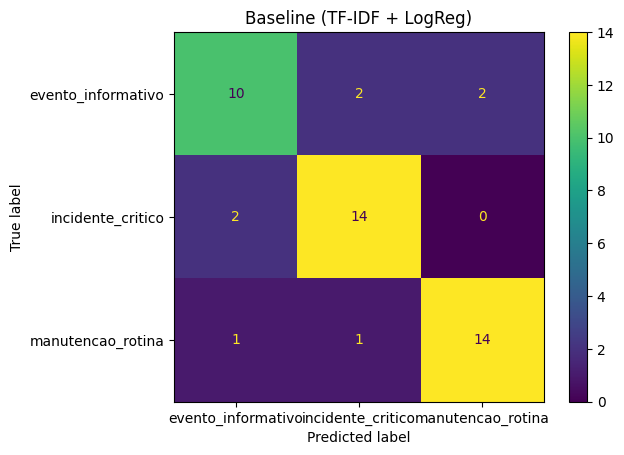

In [27]:
cm = confusion_matrix(y_teste, pred_baseline, labels=baseline.classes_)
ConfusionMatrixDisplay(cm, display_labels=baseline.classes_).plot()
plt.title("Baseline (TF-IDF + LogReg)")
plt.show()

In [28]:
from gensim.models import Word2Vec

# 1. Preparar os dados (tokenização simples dividindo por espaços)
textos_treino_tokens = [texto.lower().split() for texto in textos_treino]
textos_teste_tokens = [texto.lower().split() for texto in textos_teste]

# 2. Treinar o modelo Word2Vec (denso estático) no nosso corpus
# vector_size=100 (tamanho do embedding), window=5 (contexto de palavras vizinhas)
w2v_model = Word2Vec(sentences=textos_treino_tokens, vector_size=100, window=5, min_count=1, workers=4)

# 3. Função para calcular o vetor médio da frase (Sentence Embedding)
def get_sentence_vector(tokens, model):
    valid_tokens = [word for word in tokens if word in model.wv]
    if not valid_tokens:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[word] for word in valid_tokens], axis=0)

# Gerar embeddings para treino e teste
X_treino_w2v = np.array([get_sentence_vector(tokens, w2v_model) for tokens in textos_treino_tokens])
X_teste_w2v = np.array([get_sentence_vector(tokens, w2v_model) for tokens in textos_teste_tokens])

# 4. Treinar e Avaliar com Regressão Logística
clf_w2v = LogisticRegression(max_iter=1000)
clf_w2v.fit(X_treino_w2v, y_treino)

pred_w2v = clf_w2v.predict(X_teste_w2v)
print("--- Resultados Word2Vec ---")
print(classification_report(y_teste, pred_w2v, zero_division=0))

# Adicione o macro_f1 do Word2Vec na sua tabela de comparação final no fim do notebook!

--- Resultados Word2Vec ---
                    precision    recall  f1-score   support

evento_informativo       0.00      0.00      0.00        14
 incidente_critico       0.35      1.00      0.52        16
 manutencao_rotina       0.00      0.00      0.00        16

          accuracy                           0.35        46
         macro avg       0.12      0.33      0.17        46
      weighted avg       0.12      0.35      0.18        46



## 3. BERTimbau como Gerador de Embeddings (feature-based)

*(Executar Notebook — Slide "BERTimbau como Gerador de Embeddings")*

Usamos o token `[CLS]` como representação da sentença inteira (estratégia
feature-based vista na Aula 6/7), e treinamos o mesmo classificador leve
(Regressão Logística) em cima desses embeddings.

In [29]:
import torch
from transformers import AutoTokenizer, AutoModel

MODELO_BERTIMBAU = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(MODELO_BERTIMBAU)
bertimbau = AutoModel.from_pretrained(MODELO_BERTIMBAU)
bertimbau.eval()

@torch.no_grad()
def embeddings_cls(textos, batch_size=8):
    vetores = []
    for i in range(0, len(textos), batch_size):
        lote = textos[i:i + batch_size]
        enc = tokenizer(lote, padding=True, truncation=True, return_tensors="pt")
        saida = bertimbau(**enc)
        cls = saida.last_hidden_state[:, 0, :]  # token [CLS]
        vetores.append(cls.numpy())
    return np.vstack(vetores)

X_treino_bert = embeddings_cls(textos_treino)
X_teste_bert = embeddings_cls(textos_teste)
print("Shape dos embeddings:", X_treino_bert.shape)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Shape dos embeddings: (107, 768)


In [30]:
clf_bert = LogisticRegression(max_iter=1000)
clf_bert.fit(X_treino_bert, y_treino)

pred_bert = clf_bert.predict(X_teste_bert)
print(classification_report(y_teste, pred_bert, zero_division=0))

                    precision    recall  f1-score   support

evento_informativo       0.67      0.43      0.52        14
 incidente_critico       0.82      0.88      0.85        16
 manutencao_rotina       0.75      0.94      0.83        16

          accuracy                           0.76        46
         macro avg       0.75      0.75      0.73        46
      weighted avg       0.75      0.76      0.74        46



## 4. Comparação: Baseline vs. BERTimbau (feature-based)

Com um dataset tão pequeno, a diferença pode não ser grande — o ponto aqui é
o **pipeline**. Com um dataset real (centenas/milhares de exemplos), a
vantagem do BERTimbau tende a aparecer principalmente no **macro-F1**,
especialmente em casos de ambiguidade semântica que o TF-IDF não capta.

In [31]:
from sklearn.metrics import f1_score

comparacao = pd.DataFrame({
    "modelo": ["Baseline (TF-IDF+LogReg)", "Word2Vec (denso estático)", "BERTimbau (feature-based)"],
    "macro_f1": [
        f1_score(y_teste, pred_baseline, average="macro", zero_division=0),
        f1_score(y_teste, pred_w2v, average="macro", zero_division=0), # Linha adicionada para o Word2Vec
        f1_score(y_teste, pred_bert, average="macro", zero_division=0),
    ],
}).set_index("modelo").round(3)

comparacao

,macro_f1
modelo,
Baseline (TF-IDF+LogReg),0.821
Word2Vec (denso estático),0.172
BERTimbau (feature-based),0.735


## 5. Fine-tuning Completo com Hugging Face `Trainer`

*(Executar Notebook — Slide "Fine-tuning com Hugging Face")*

Agora vamos além do feature-based: ajustamos **todos os pesos** do BERTimbau
para a nossa tarefa, usando `AutoModelForSequenceClassification` + `Trainer`.

> Com poucas dezenas de exemplos e poucas épocas, não espere um resultado
> impressionante — o objetivo é você entender o pipeline completo de
> fine-tuning para aplicar depois com um dataset real e mais épocas/dados.

In [32]:
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification, TrainingArguments, Trainer,
    DataCollatorWithPadding,
)

classes = sorted(df["classe"].unique())
label2id = {c: i for i, c in enumerate(classes)}
id2label = {i: c for c, i in label2id.items()}

ds_treino = Dataset.from_dict({
    "text": textos_treino,
    "label": [label2id[c] for c in y_treino],
})
ds_teste = Dataset.from_dict({
    "text": textos_teste,
    "label": [label2id[c] for c in y_teste],
})

def tokenizar(exemplo):
    return tokenizer(exemplo["text"], truncation=True)

ds_treino_tok = ds_treino.map(tokenizar, batched=True)
ds_teste_tok = ds_teste.map(tokenizar, batched=True)

modelo_ft = AutoModelForSequenceClassification.from_pretrained(
    MODELO_BERTIMBAU, num_labels=len(classes), id2label=id2label, label2id=label2id,
)

args = TrainingArguments(
    output_dir="./resultado_finetuning",
    num_train_epochs=4,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    logging_steps=5,
    report_to="none",
)

trainer = Trainer(
    model=modelo_ft,
    args=args,
    train_dataset=ds_treino_tok,
    eval_dataset=ds_teste_tok,
    data_collator=DataCollatorWithPadding(tokenizer),
)

trainer.train()

Map:   0%|          | 0/107 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Epoch,Training Loss,Validation Loss
1,1.038036,0.790990
2,0.505812,0.453243
3,0.127259,0.236775
4,0.053238,0.249850


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=56, training_loss=0.44679268449544907, metrics={'train_runtime': 102.6874, 'train_samples_per_second': 4.168, 'train_steps_per_second': 0.545, 'total_flos': 4457511299556.0, 'train_loss': 0.44679268449544907, 'epoch': 4.0})

In [33]:
predicoes = trainer.predict(ds_teste_tok)
pred_ft = np.argmax(predicoes.predictions, axis=1)
pred_ft_labels = [id2label[i] for i in pred_ft]

print(classification_report(y_teste, pred_ft_labels, zero_division=0))

                    precision    recall  f1-score   support

evento_informativo       0.86      0.86      0.86        14
 incidente_critico       0.88      0.88      0.88        16
 manutencao_rotina       1.00      1.00      1.00        16

          accuracy                           0.91        46
         macro avg       0.91      0.91      0.91        46
      weighted avg       0.91      0.91      0.91        46



## 6. Análise de Erros

*(Executar Notebook — Slide "Análise de Erros")*

Vamos inspecionar quais mensagens o modelo fine-tuned errou, e por quê.

In [34]:
erros = pd.DataFrame({
    "texto": textos_teste,
    "classe_real": y_teste,
    "classe_predita": pred_ft_labels,
})
erros["acertou"] = erros["classe_real"] == erros["classe_predita"]

print(f"Acuracia no teste: {erros['acertou'].mean():.2%}")
erros[~erros["acertou"]]

Acuracia no teste: 91.30%


,texto,classe_real,classe_predita,acertou
12,Pressao na rede do setor Sul dentro da faixa o...,evento_informativo,incidente_critico,False
20,Comunicacao com RTU da Captacao Rio Verde inte...,incidente_critico,evento_informativo,False
30,Nível do reservatório R-01 em faixa crítica,incidente_critico,evento_informativo,False
40,Pressão da adutora dentro da faixa operacional,evento_informativo,incidente_critico,False


### Perguntas para discussão (Aula 4)
- Os erros estão concentrados em alguma classe específica (ver matriz de confusão)?
- Eles se devem a **ambiguidade real** na mensagem ou a **poucos dados de treino**?
- O que aconteceria se dobrássemos o número de exemplos por classe?

## 7. Extensão opcional: interface com Gradio

Só para fechar com a "Extensões e Aplicações Futuras" do slide — um app web
mínimo para testar o classificador interativamente (opcional, requer `gradio`
instalado; não precisa rodar em lote/CI).

In [35]:
# !pip install -q gradio
# import gradio as gr
#
# def classificar(mensagem):
#     enc = tokenizer(mensagem, return_tensors="pt", truncation=True)
#     with torch.no_grad():
#         logits = modelo_ft(**enc).logits
#     classe = id2label[int(logits.argmax())]
#     return classe
#
# gr.Interface(fn=classificar, inputs="text", outputs="text").launch()

## Fechamento

Você acabou de percorrer o pipeline completo: baseline → embeddings
contextuais → fine-tuning → análise crítica dos erros. Esse é o mesmo
esqueleto que reaparecerá, em versões mais sofisticadas, quando tratarmos
RAG (Aulas 11–13) e agentes (Aula 10 em diante).